# Phase 0 - WASP-121b: reproduce Huang+2023 Case A / Case A$'$

This notebook compares two converged EXHALE runs in this folder against the
spherical reference model of **Huang, Koskinen, Lavvas & Fossati (2023, ApJ 951, 123)**:

| run directory        | metals            | ~ Huang case |
|----------------------|-------------------|--------------|
| `output_metals_on/`  | C, N, O trace     | Case A       |
| `output_metals_off/` | H/He only         | Case A$'$    |

**Huang Case A reference targets (Table 3 / Fig. 9):**
spherical mass-loss rate $\dot M = 3.72\times10^{12}\,$g s$^{-1}$ ($=0.052\,M_p\,$Gyr$^{-1}$,
$\log_{10}\dot M = 12.57$) and a temperature peak of $\approx 12{,}000\,$K.

**Two caveats when reading the comparison:**
1. *Geometry.* Huang Case A is **spherical** and extends to $\sim$19 $R_p$.
   ATES always includes the full Roche (tidal + centrifugal) potential and
   truncates the domain at the Hill/L1 radius, here $r_{\max}\approx2.0\,R_p$.
   The tidal field lowers the escape barrier, so a small upward shift of
   $\dot M$ relative to the spherical value is expected.
2. *Metal set.* Huang Case A carries Mg, Fe, Si, Ca, Na, K, S (Mg II / Fe II
   dominate the cooling at 1.15-1.4 $R_p$). This Phase-0 run has **only C/N/O**;
   the remaining metals are added in Phase 1. So `output_metals_on/` is an
   approximation to Case A, not a like-for-like match.

All radii are in units of the planet radius $R_p = 1.766\,R_J$ (the ATES inner
boundary). Number densities are total per cm$^3$; the lower boundary is set at
1 $\mu$bar ($n_0 = 10^{12.49}\,$cm$^{-3}$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

m_H   = 1.6726219e-24      # g
GAMMA = 5.0/3.0            # adiabatic index

# --- Huang+2023 Case A reference targets ---
HUANG_LOGMDOT = np.log10(3.72e12)   # = 12.57
HUANG_MDOT    = 3.72e12             # g/s
HUANG_TPEAK   = 12000.0             # K
RP_RJ         = 1.766               # optical radius [R_J]

def load_run(path):
    h = np.loadtxt(f"{path}/Hydro_ioniz.txt")
    s = np.loadtxt(f"{path}/Ion_species.txt")
    r, n_tot, v, p, T, heat, cool = (h[:, i] for i in range(7))
    d = dict(r=r, n_tot=n_tot, v=v, p=p, T=T, heat=heat, cool=cool)
    names = ["nHI","nHII","nHeI","nHeII","nHeIII","nHeITR",
             "nCI","nCII","nCIII","nOI","nOII","nOIII","nNI","nNII","nNIII"]
    for i, nm in enumerate(names, start=1):
        d[nm] = s[:, i]
    # mass density (electrons negligible) -> adiabatic sound speed & Mach
    rho = m_H*((d["nHI"]+d["nHII"])
               + 4.0*(d["nHeI"]+d["nHeII"]+d["nHeIII"])
               + 12.0*(d["nCI"]+d["nCII"]+d["nCIII"])
               + 16.0*(d["nOI"]+d["nOII"]+d["nOIII"])
               + 14.0*(d["nNI"]+d["nNII"]+d["nNIII"]))
    d["rho"]  = rho
    d["cs"]   = np.sqrt(GAMMA*p/rho)
    d["mach"] = v/d["cs"]
    d["xHII"] = d["nHII"]/np.maximum(d["nHI"]+d["nHII"], 1e-99)
    d["phys"] = (r >= 1.0) & (r <= r.max())
    return d

def read_logMdot(path):
    for line in open(f"{path}/ATES.out"):
        if "steady-state Mdot" in line:
            return float(line.split("=")[1].split("g/s")[0])
    return np.nan

A  = load_run("output_metals_on")    # Case A  (C/N/O)
Ap = load_run("output_metals_off")   # Case A' (H/He)
A["logMdot"]  = read_logMdot("output_metals_on")
Ap["logMdot"] = read_logMdot("output_metals_off")

LBL_A  = r"Case A (C/N/O)"
LBL_AP = r"Case A$^\prime$ (H/He)"
print("loaded:", LBL_A, "logMdot=%.2f" % A["logMdot"],
      "|", LBL_AP, "logMdot=%.2f" % Ap["logMdot"])

loaded: Case A (C/N/O) logMdot=12.68 | Case A$^\prime$ (H/He) logMdot=12.92


## Summary table

`r(sonic)` is the first $v/c_s = 1$ crossing; `r(x_HII=0.5)` is where hydrogen
reaches 50% ionization. The Huang column is the spherical Case A reference.

In [2]:
def derived(d):
    ph = d["phys"]; r = d["r"][ph]; T = d["T"][ph]; mach = d["mach"][ph]; x = d["xHII"][ph]
    ipk = np.argmax(T)
    cs_  = np.where(np.diff(np.sign(mach-1.0)) > 0)[0]
    c50  = np.where(np.diff(np.sign(x-0.5))   > 0)[0]
    return dict(Tpeak=T[ipk], rTpeak=r[ipk],
                rsonic=(r[cs_[0]] if cs_.size else np.nan),
                rxhii=(r[c50[0]] if c50.size else np.nan), rmax=r.max())

gA, gAp = derived(A), derived(Ap)
hdr = f"{'quantity':20s}{'Case A (CNO)':>16s}{'Case A-prime':>16s}{'Huang A':>14s}"
print(hdr); print('-'*len(hdr))
print(f"{'log10 Mdot [g/s]':20s}{A['logMdot']:>16.2f}{Ap['logMdot']:>16.2f}{HUANG_LOGMDOT:>14.2f}")
print(f"{'Mdot [g/s]':20s}{10**A['logMdot']:>16.2e}{10**Ap['logMdot']:>16.2e}{HUANG_MDOT:>14.2e}")
print(f"{'Mdot / Huang':20s}{10**(A['logMdot']-HUANG_LOGMDOT):>16.2f}{10**(Ap['logMdot']-HUANG_LOGMDOT):>16.2f}{1.0:>14.2f}")
print(f"{'T peak [K]':20s}{gA['Tpeak']:>16.0f}{gAp['Tpeak']:>16.0f}{HUANG_TPEAK:>14.0f}")
print(f"{'r(T peak) [Rp]':20s}{gA['rTpeak']:>16.3f}{gAp['rTpeak']:>16.3f}{'-':>14s}")
print(f"{'r(sonic) [Rp]':20s}{gA['rsonic']:>16.3f}{gAp['rsonic']:>16.3f}{'-':>14s}")
print(f"{'r(xHII=0.5) [Rp]':20s}{gA['rxhii']:>16.3f}{gAp['rxhii']:>16.3f}{'-':>14s}")
print(f"{'domain r_max [Rp]':20s}{gA['rmax']:>16.3f}{gAp['rmax']:>16.3f}{'~19':>14s}")

quantity                Case A (CNO)    Case A-prime       Huang A
------------------------------------------------------------------
log10 Mdot [g/s]               12.68           12.92         12.57
Mdot [g/s]                  4.79e+12        8.32e+12      3.72e+12
Mdot / Huang                    1.29            2.24          1.00
T peak [K]                      9662           13722         12000
r(T peak) [Rp]                 1.199           1.703             -
r(sonic) [Rp]                  1.819           1.785             -
r(xHII=0.5) [Rp]               1.177           1.218             -
domain r_max [Rp]              2.012           2.012           ~19


## Fig. 1 - Temperature profile (compare with Huang Fig. 9)

Horizontal line = Huang Case A peak (12,000 K). Vertical lines mark each model's
sonic point. Note that the C/N/O cooling pulls the Case A peak inward and below
the H/He-only Case A$'$ peak.

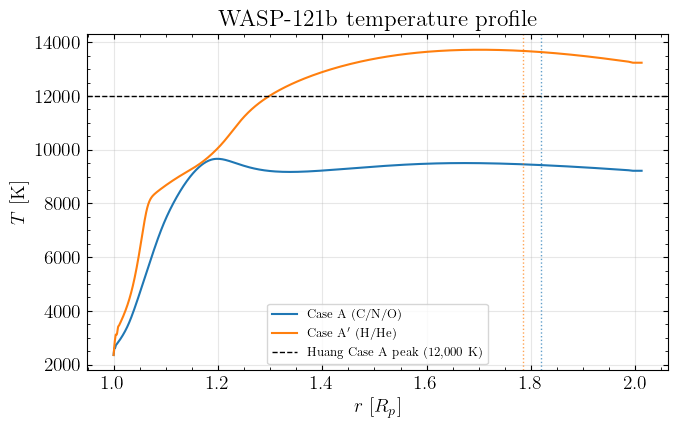

In [3]:
fig, ax = plt.subplots(figsize=(7,4.5))
for d, lbl, c in [(A, LBL_A, 'C0'), (Ap, LBL_AP, 'C1')]:
    ph = d["phys"]
    ax.plot(d["r"][ph], d["T"][ph], color=c, label=lbl)
    g = derived(d)
    ax.axvline(g["rsonic"], color=c, ls=':', lw=1, alpha=0.7)
ax.axhline(HUANG_TPEAK, color='k', ls='--', lw=1, label=r'Huang Case A peak (12{,}000 K)')
ax.set_xlabel(r'$r\ [R_p]$'); ax.set_ylabel(r'$T\ [\mathrm{K}]$')
ax.set_title(r'WASP-121b temperature profile')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Fig. 2 - Velocity, sound speed and Mach number

The sonic transition ($v=c_s$) lies inside the truncated domain, so the
steady-state $\dot M = 4\pi r^2\rho v$ measured near the outer boundary is on the
supersonic branch and is meaningful.

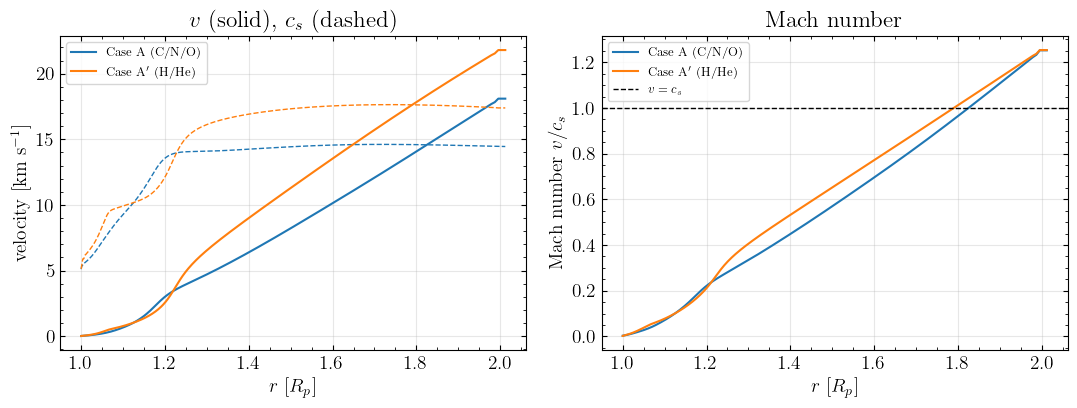

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,4.3))
for d, lbl, c in [(A, LBL_A, 'C0'), (Ap, LBL_AP, 'C1')]:
    ph = d["phys"]
    ax1.plot(d["r"][ph], d["v"][ph]/1e5, color=c, label=lbl)
    ax1.plot(d["r"][ph], d["cs"][ph]/1e5, color=c, ls='--', lw=1)
    ax2.plot(d["r"][ph], d["mach"][ph], color=c, label=lbl)
ax1.set_xlabel(r'$r\ [R_p]$'); ax1.set_ylabel(r'velocity [km s$^{-1}$]')
ax1.set_title(r'$v$ (solid), $c_s$ (dashed)'); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax2.axhline(1.0, color='k', ls='--', lw=1, label=r'$v=c_s$')
ax2.set_xlabel(r'$r\ [R_p]$'); ax2.set_ylabel(r'Mach number $v/c_s$')
ax2.set_title(r'Mach number'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Fig. 3 - Hydrogen and helium ionization

Left: H I / H II number fractions. Right: He I / He II / He III fractions.
The 50% H-ionization radius is marked.

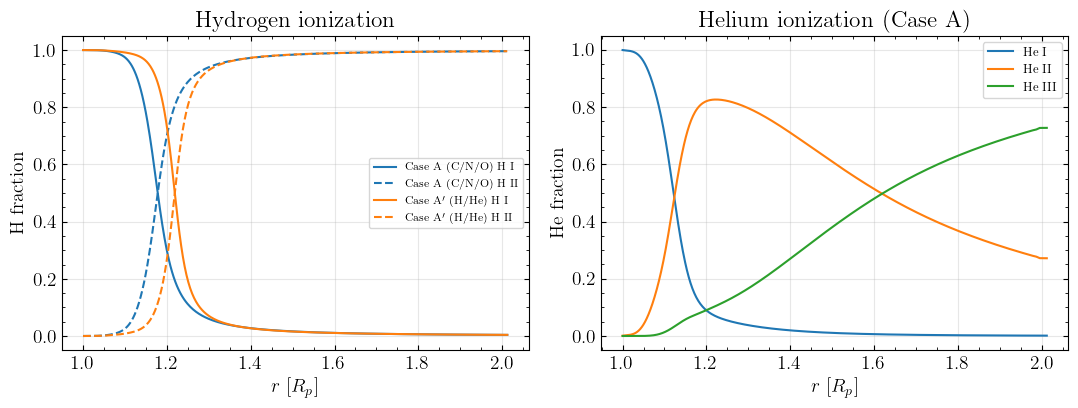

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,4.3))
for d, lbl, c in [(A, LBL_A, 'C0'), (Ap, LBL_AP, 'C1')]:
    ph = d["phys"]; r = d["r"][ph]
    tot = d["nHI"][ph]+d["nHII"][ph]
    ax1.plot(r, d["nHI"][ph]/tot,  color=c, ls='-',  label=lbl+r' H I')
    ax1.plot(r, d["nHII"][ph]/tot, color=c, ls='--', label=lbl+r' H II')
ax1.set_xlabel(r'$r\ [R_p]$'); ax1.set_ylabel(r'H fraction')
ax1.set_title(r'Hydrogen ionization'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
# Helium for Case A only (qualitatively identical for A')
ph = A["phys"]; r = A["r"][ph]
heT = A["nHeI"][ph]+A["nHeII"][ph]+A["nHeIII"][ph]
ax2.plot(r, A["nHeI"][ph]/heT,   label=r'He I')
ax2.plot(r, A["nHeII"][ph]/heT,  label=r'He II')
ax2.plot(r, A["nHeIII"][ph]/heT, label=r'He III')
ax2.set_xlabel(r'$r\ [R_p]$'); ax2.set_ylabel(r'He fraction')
ax2.set_title(r'Helium ionization (Case A)'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Fig. 4 - Metal ionization (Case A, C/N/O)

Ionization stages of carbon, nitrogen and oxygen. Huang (Fig. 12) finds the
heavier metals mostly doubly ionized in the upper thermosphere; here we only
carry C/N/O, shown as fractions of each element.

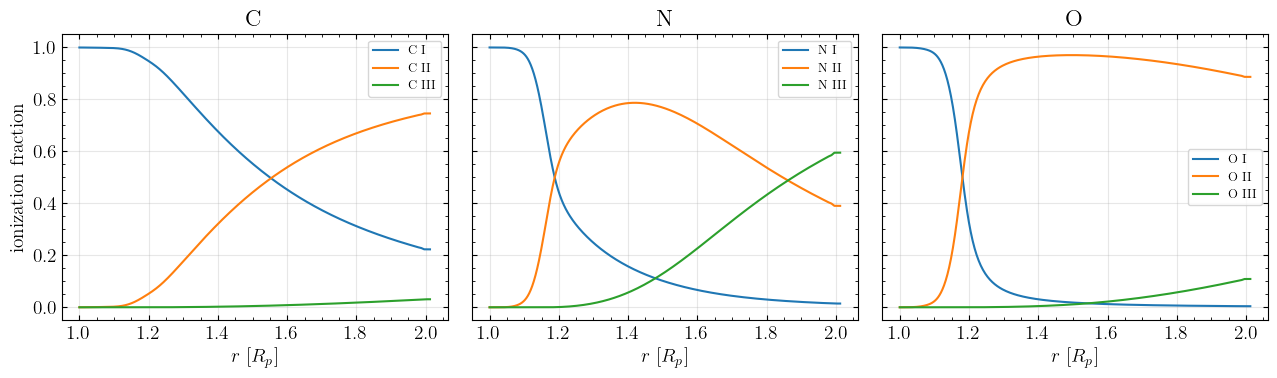

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13,4.0), sharey=True)
ph = A["phys"]; r = A["r"][ph]
for ax, el, (i,ii,iii) in zip(
        axes, ['C','N','O'],
        [("nCI","nCII","nCIII"),("nNI","nNII","nNIII"),("nOI","nOII","nOIII")]):
    tot = A[i][ph]+A[ii][ph]+A[iii][ph]
    tot = np.maximum(tot, 1e-99)
    ax.plot(r, A[i][ph]/tot,   label=el+r' I')
    ax.plot(r, A[ii][ph]/tot,  label=el+r' II')
    ax.plot(r, A[iii][ph]/tot, label=el+r' III')
    ax.set_xlabel(r'$r\ [R_p]$'); ax.set_title(el); ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[0].set_ylabel(r'ionization fraction')
plt.tight_layout(); plt.show()

## Fig. 5 - Density, pressure, radiative heating and cooling

Heating and cooling are volumetric rates [erg cm$^{-3}$ s$^{-1}$]. The extra
C/N/O cooling channel in Case A is what lowers its temperature relative to
Case A$'$.

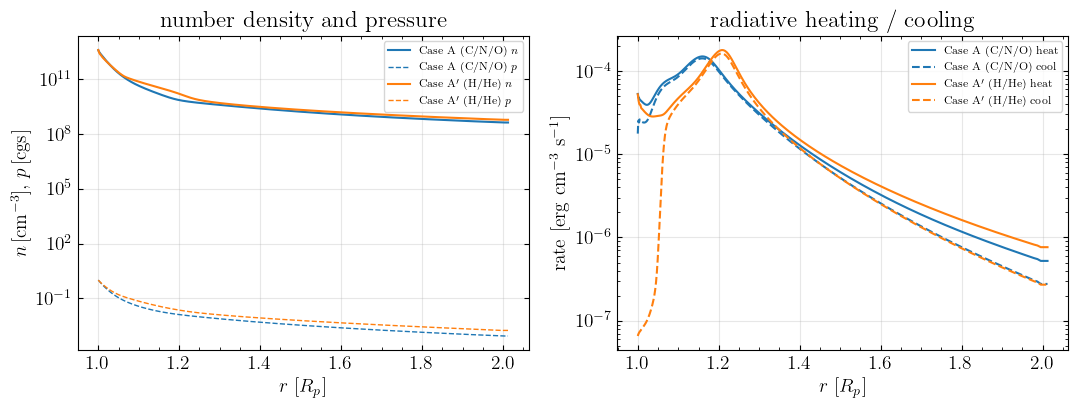

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,4.3))
for d, lbl, c in [(A, LBL_A, 'C0'), (Ap, LBL_AP, 'C1')]:
    ph = d["phys"]; r = d["r"][ph]
    ax1.semilogy(r, d["n_tot"][ph], color=c, label=lbl+r' $n$')
    ax1.semilogy(r, d["p"][ph],     color=c, ls='--', lw=1, label=lbl+r' $p$')
    ax2.semilogy(r, np.maximum(d["heat"][ph],1e-99), color=c, ls='-',  label=lbl+r' heat')
    ax2.semilogy(r, np.maximum(d["cool"][ph],1e-99), color=c, ls='--', label=lbl+r' cool')
ax1.set_xlabel(r'$r\ [R_p]$'); ax1.set_ylabel(r'$n\,[\mathrm{cm}^{-3}]$, $p\,[\mathrm{cgs}]$')
ax1.set_title(r'number density and pressure'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax2.set_xlabel(r'$r\ [R_p]$'); ax2.set_ylabel(r'rate [erg cm$^{-3}$ s$^{-1}$]')
ax2.set_title(r'radiative heating / cooling'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()